# Monte Carlo Simulation

### GBM Simulation

In [1]:
import numpy as np
from scipy.stats import norm
import matplotlib.pyplot as plt

def simulate_paths(S, T, r, sigma, n_step, n_sim , seed=42):
    np.random.seed(seed)
    dt = T / n_step
    
    # Generate a matrix of Z ~ N(0, 1) with dimensions (nb of scenarios, nb of steps)
    Z = np.random.standard_normal((n_sim, n_step))
    growth = np.exp((r - 0.5 * sigma**2) * dt + sigma * np.sqrt(dt) * Z) # formula 10.12
    
    # Paths matrix dimension (nb of scenarios, nb of steps + 1)
    paths = np.ones((n_sim, n_step + 1)) * S
    paths[:, 1:] = S * np.cumprod(growth, axis=1)
    
    return paths

### Monte Carlo

In [2]:
def monte_carlo(S, K, T, r, sigma, n_step, n_sim, option_type='call'):
    # Simulate
    paths = simulate_paths(S, T, r, sigma, n_step=252, n_sim=10000)
    
    # Compute payoffs
    sign = 1 if option_type == 'call' else -1
    payoff = np.maximum(sign * (paths[:, -1] - K), 0)

    # Option value
    price = np.exp(-r * T) * np.mean(payoff)
    
    # Standard Error: SE = std(payoffs) / sqrt(N)  [from CLT]
    se = np.exp(-r * T) * np.std(payoff, ddof=1) / np.sqrt(len(payoff))

    return price, se

### Black-Scholes & Binomial Tree (CRR)

In [3]:
def black_scholes(S, K, T, r, sigma, option_type='call'):
    d1 = (np.log(S / K) + (r + 0.5 * sigma**2) * T) / (sigma * np.sqrt(T))
    d2 = d1 - sigma * np.sqrt(T)
    if option_type == 'call':
        return S * norm.cdf(d1) - K * np.exp(-r * T) * norm.cdf(d2)
    else:
        return K * np.exp(-r * T) * norm.cdf(-d2) - S * norm.cdf(-d1)

def binomial_crr(S, K, T, r, sigma, n, option_type='call'):
    dt   = T / n
    u    = np.exp(sigma * np.sqrt(dt))
    d    = 1 / u
    q    = (np.exp(r * dt) - d) / (u - d)
    df   = np.exp(-r * dt)
    sign = 1 if option_type == 'call' else -1

    prices = S * (u ** np.arange(n, -1, -1)) * (d ** np.arange(n + 1))
    values = np.maximum(sign * (prices - K), 0)
    for _ in range(n):
        values = df * (q * values[:-1] + (1 - q) * values[1:])
    return values[0]

### Sanity Check

In [4]:
S, K, T, r, sigma = 100.0, 100.0, 1.0, 0.05, 0.20
n_step, n_sim = 252, 10000

bs_call = black_scholes(S, K, T, r, sigma, 'call')
bs_put  = black_scholes(S, K, T, r, sigma, 'put')
bm_call = binomial_crr(S, K, T, r, sigma, n=1000, option_type='call')
bm_put  = binomial_crr(S, K, T, r, sigma, n=1000, option_type='put')
mc_call, se_call = monte_carlo(S, K, T, r, sigma, n_step, n_sim, option_type='call')
mc_put, se_put = monte_carlo(S, K, T, r, sigma, n_step, n_sim, option_type='put')

# --- Summary Table ---
print(f"{'Method':<28} {'Call':>8} {'Put':>8}  {'95% CI Call'}")
print("-" * 60)
print(f"{'Black-Scholes (exact)':<28} {bs_call:>8.4f} {bs_put:>8.4f}  {'exact'}")
print(f"{'Binomial CRR (n=1000)':<28} {bm_call:>8.4f} {bm_put:>8.4f}  {'< 0.001'}")
print(f"{'Monte Carlo (N=100k)':<28} {mc_call:>8.4f} {mc_put:>8.4f}  ± {1.96*se_call:.4f}")

Method                           Call      Put  95% CI Call
------------------------------------------------------------
Black-Scholes (exact)         10.4506   5.5735  exact
Binomial CRR (n=1000)         10.4486   5.5715  < 0.001
Monte Carlo (N=100k)          10.2211   5.5292  ± 0.2834


### Convergence Experiment

In [5]:
# --- Convergence experiment ---
N_values   = [100, 300, 1_000, 3_000, 10_000, 30_000, 100_000]
bs_ref     = black_scholes(S, K, T, r, sigma, 'call')   # ground truth

mc_prices, mc_errors, mc_se_list = [], [], []

for N in N_values:
    p      = simulate_paths(S, T, r, sigma, n_step=252, n_sim=N, seed=7)
    pf     = np.maximum(p[:, -1] - K, 0)
    price  = np.exp(-r * T) * np.mean(pf)
    se     = np.exp(-r * T) * np.std(pf, ddof=1) / np.sqrt(N)

    mc_prices.append(price)
    mc_errors.append(abs(price - bs_ref))
    mc_se_list.append(se)

print(f"\n{'N':>8} | {'MC Price':>10} | {'|Error|':>9} | {'Std Error':>10} | {'95% CI contains BS?'}")
print("-" * 72)
for i, N in enumerate(N_values):
    lo = mc_prices[i] - 1.96 * mc_se_list[i]
    hi = mc_prices[i] + 1.96 * mc_se_list[i]
    inside = "✓" if lo <= bs_ref <= hi else "✗"
    print(f"{N:>8} | {mc_prices[i]:>10.4f} | {mc_errors[i]:>9.4f} | "
          f"{mc_se_list[i]:>10.4f} | {inside}  [{lo:.3f}, {hi:.3f}]")


       N |   MC Price |   |Error| |  Std Error | 95% CI contains BS?
------------------------------------------------------------------------
     100 |    10.9774 |    0.5269 |     1.5310 | ✓  [7.977, 13.978]
     300 |    10.0216 |    0.4290 |     0.7838 | ✓  [8.485, 11.558]
    1000 |    10.3960 |    0.0546 |     0.4519 | ✓  [9.510, 11.282]
    3000 |    10.6429 |    0.1924 |     0.2722 | ✓  [10.109, 11.177]
   10000 |    10.5254 |    0.0748 |     0.1473 | ✓  [10.237, 10.814]
   30000 |    10.4175 |    0.0331 |     0.0841 | ✓  [10.253, 10.582]
  100000 |    10.4259 |    0.0247 |     0.0465 | ✓  [10.335, 10.517]


### Convergence Plot (example)

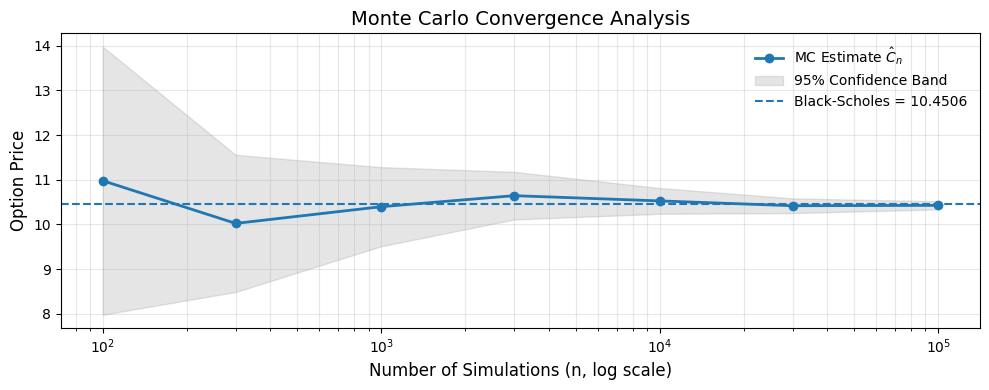

In [6]:
fig, ax = plt.subplots(figsize=(10, 4))

# --- Left: price convergence with CI band ---
lo_band = [p - 1.96 * s for p, s in zip(mc_prices, mc_se_list)]
hi_band = [p + 1.96 * s for p, s in zip(mc_prices, mc_se_list)]

ax.semilogx(N_values, mc_prices, 'o-', lw=2, label='MC Estimate $\\hat{C}_n$')
ax.fill_between(N_values, lo_band, hi_band, alpha=0.20, color='grey', label='95% Confidence Band')
ax.axhline(bs_ref, lw=1.5, linestyle='--', label=f'Black-Scholes = {bs_ref:.4f}')

ax.set_xlabel('Number of Simulations (n, log scale)', fontsize=12)
ax.set_ylabel('Option Price', fontsize=12)
ax.set_title('Monte Carlo Convergence Analysis', fontsize=14)
ax.grid(True, which='both', alpha=0.3)
ax.legend(frameon=False)

plt.tight_layout()
plt.show()